# K-Means Clustering on German Credit Data

In [233]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [234]:
df = pd.read_csv("german_credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [235]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [236]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [237]:
df.isnull().sum()
df.duplicated().sum()

0

In [238]:
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_pct})
missing_data = missing_data[missing_data["Missing Values"] > 0].sort_values(by="Percentage", ascending=False)
missing_data.style.background_gradient(cmap='Reds', subset=['Percentage']).format({"Percentage": "{:.2f}%"})


,Missing Values,Percentage
Checking account,394,39.40%
Saving accounts,183,18.30%


In [239]:
df.nunique()


Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
dtype: int64

Sex: 2 unique values


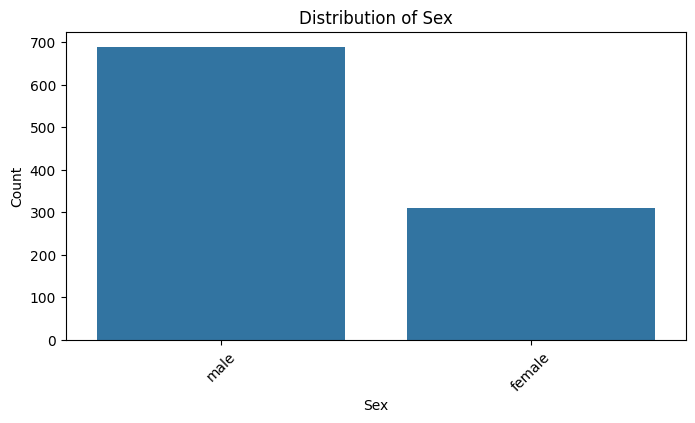

Housing: 3 unique values


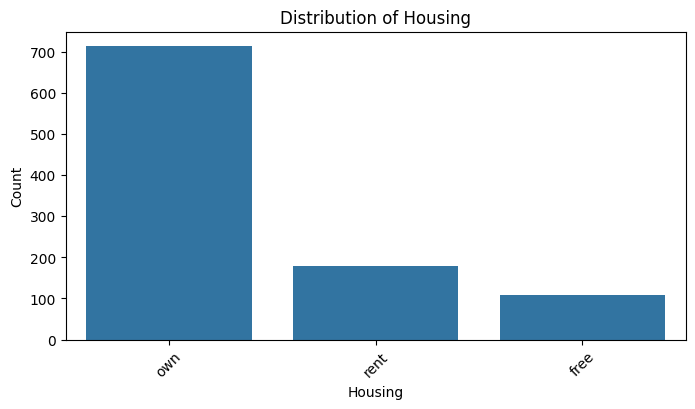

Saving accounts: 4 unique values


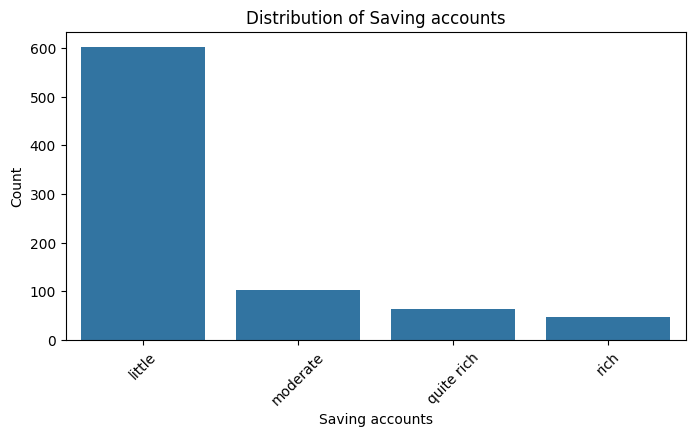

Checking account: 3 unique values


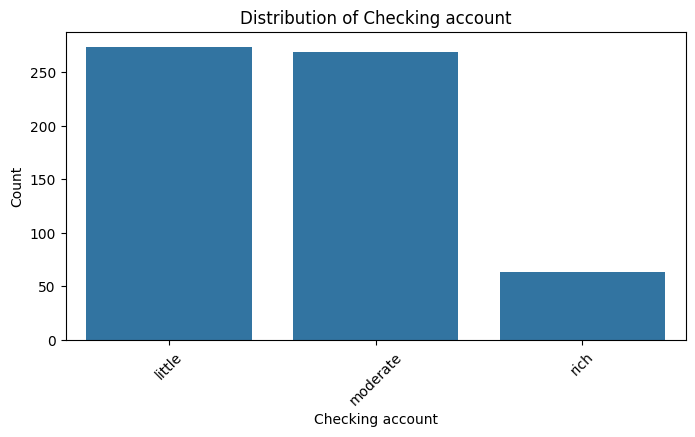

Purpose: 8 unique values


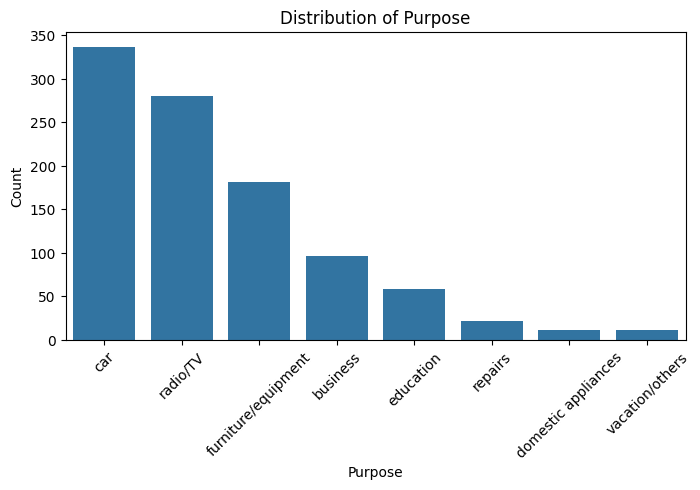

In [240]:
cat_columns = df.select_dtypes(include=['object']).columns
for col in cat_columns:
    print(f"{col}: {df[col].nunique()} unique values")
    counts = df[col].value_counts()
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

<Axes: xlabel='Credit amount', ylabel='Age'>

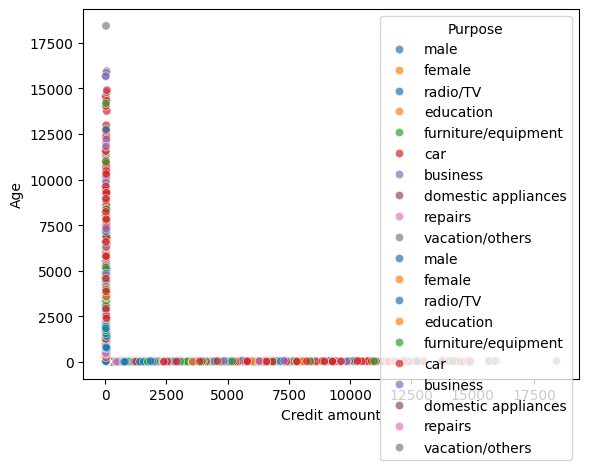

In [241]:
sns.scatterplot(data=df, x='Credit amount', y='Age', hue='Sex', alpha=0.7)
sns.scatterplot(data=df, x='Credit amount', y='Duration', hue='Purpose', alpha=0.7)
sns.scatterplot(data=df, x='Age', y='Duration', hue='Sex', alpha=0.7)
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Purpose', alpha=0.7)


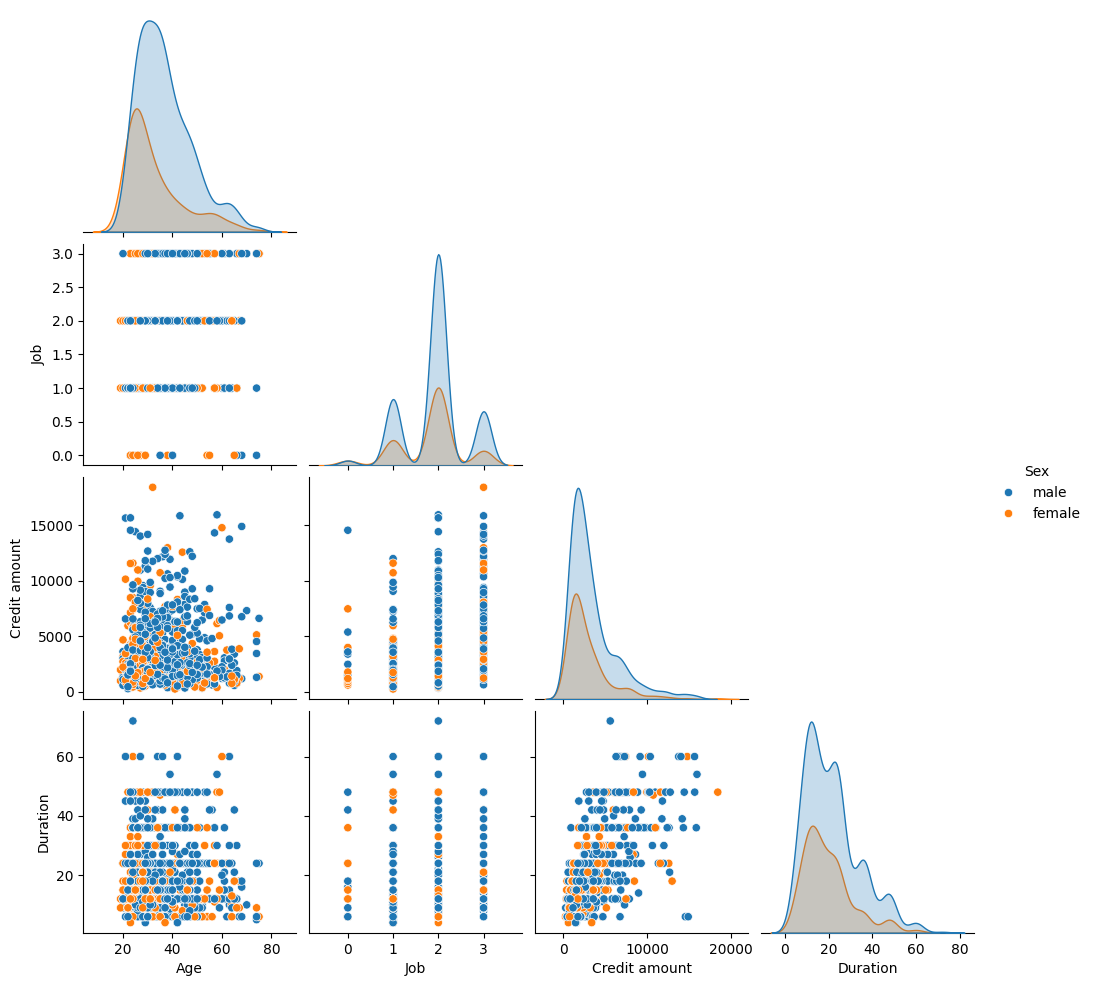

In [242]:
sns.pairplot(df, hue='Sex', diag_kind='kde', corner=True)

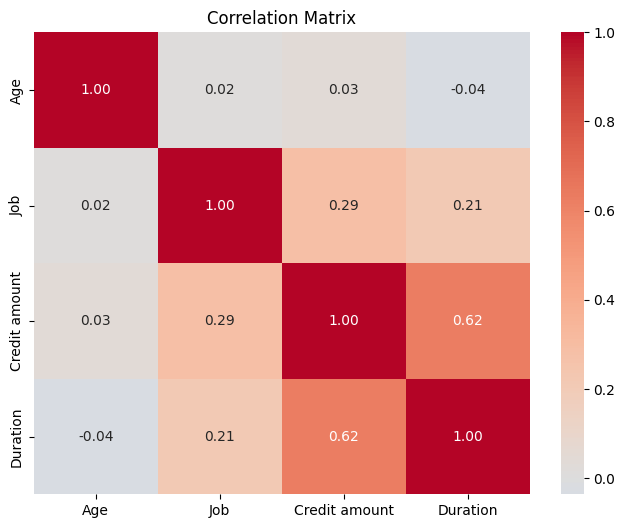

In [243]:
num_cols=df.select_dtypes(include='number').columns
num_cols = df.select_dtypes(include='number').columns
cor = df[num_cols].corr()
cor.style.background_gradient(cmap='coolwarm').format("{:.2f}")
plt.figure(figsize=(8, 6))
sns.heatmap(cor, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


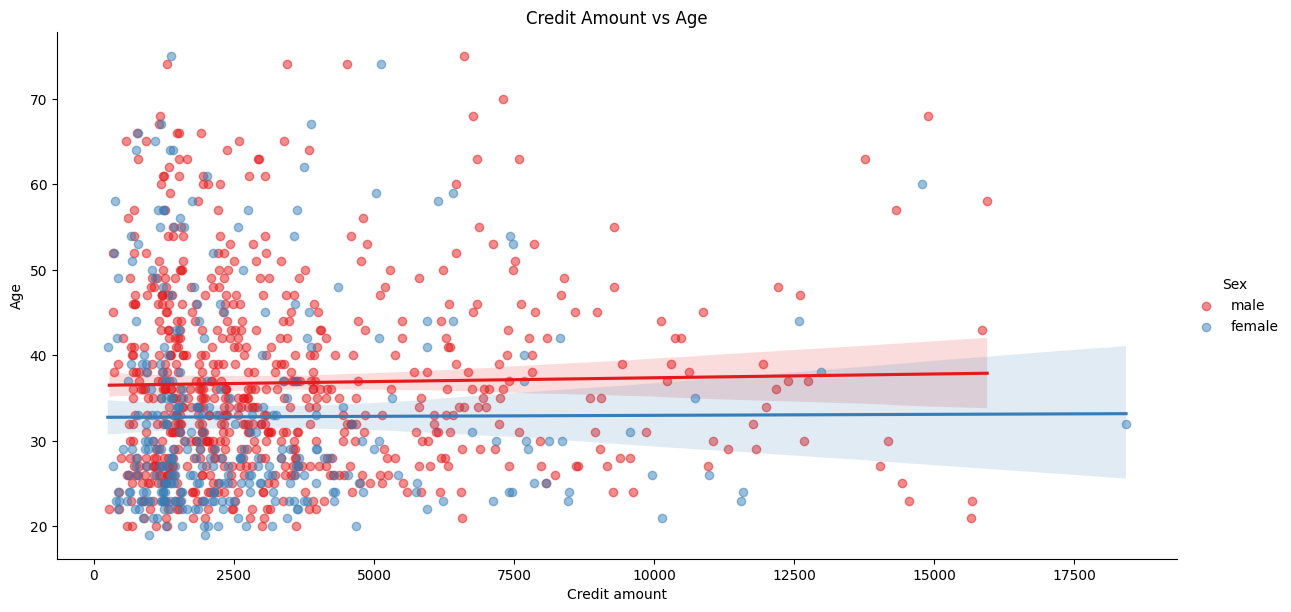

In [244]:
sns.lmplot(data=df, x='Credit amount', y='Age', aspect=2, height=6,palette='Set1', scatter_kws={'alpha':0.5},hue='Sex')
plt.title('Credit Amount vs Age')
plt.show()

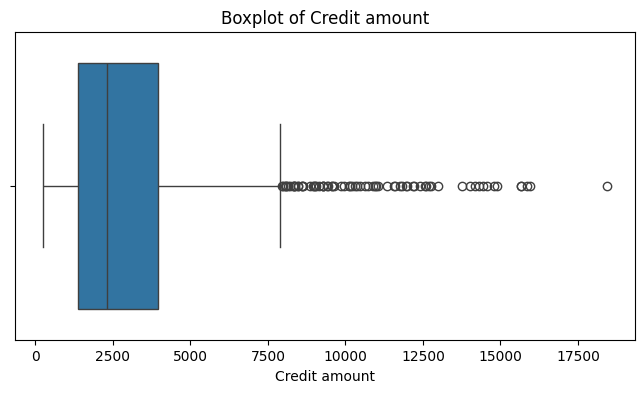

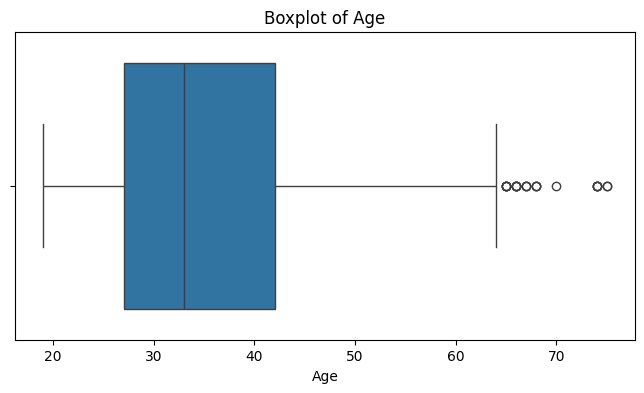

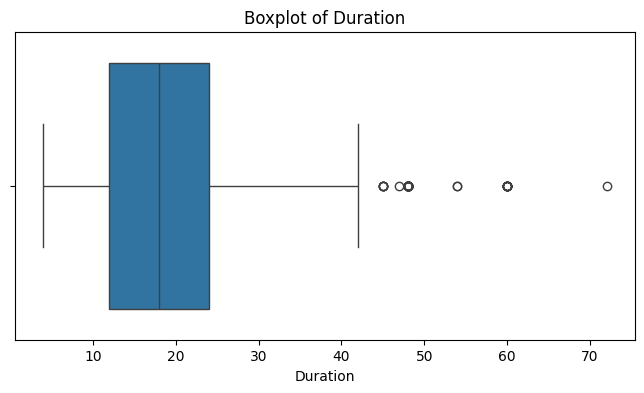

In [245]:
boxplot_cols = ['Credit amount', 'Age', 'Duration']
for col in boxplot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [246]:
def outlier_detect (df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers


In [247]:
data_clipped = outlier_detect(df, 'Age')

data_clipped


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
75,66,male,3,free,little,little,1526,12,car
137,66,male,1,own,quite rich,moderate,766,12,radio/TV
163,70,male,3,free,little,moderate,7308,10,car
179,65,male,2,own,little,little,571,21,car
186,74,female,3,free,little,moderate,5129,9,car
187,68,male,0,free,little,moderate,1175,16,car
213,66,male,3,own,little,rich,1908,30,business
330,75,male,3,free,little,little,6615,24,car
430,74,male,1,own,little,NaN,3448,5,business


In [248]:
def z_score_outlier_detect(df, col):

    mean = df[col].mean()
    std = df[col].std()

    z_scores = (df[col] - mean) / std

    outliers = df[abs(z_scores) > 3]

    return outliers

In [249]:

outliers = z_score_outlier_detect(df, "Age")

print(outliers)

     Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
163   70    male    3    free          little         moderate           7308   
186   74  female    3    free          little         moderate           5129   
330   75    male    3    free          little           little           6615   
430   74    male    1     own          little              NaN           3448   
536   75  female    3     own             NaN           little           1374   
606   74    male    3     own          little              NaN           4526   
756   74    male    0     own          little             rich           1299   

     Duration   Purpose  
163        10       car  
186         9       car  
330        24       car  
430         5  business  
536         6       car  
606        24  business  
756         6       car  


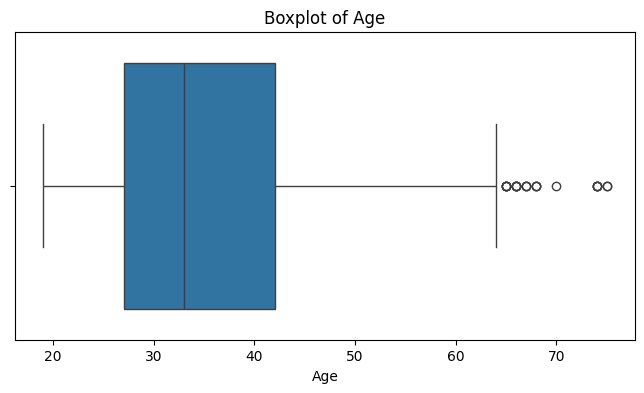

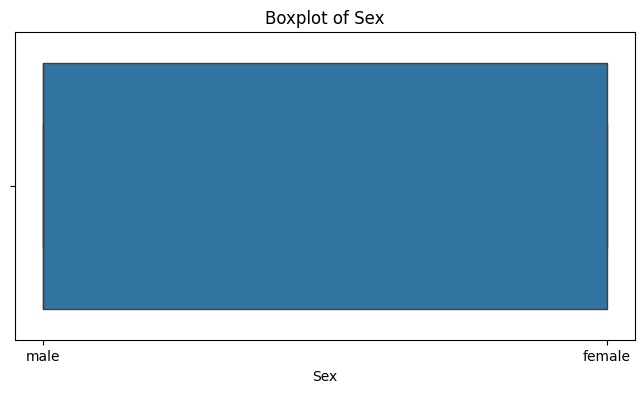

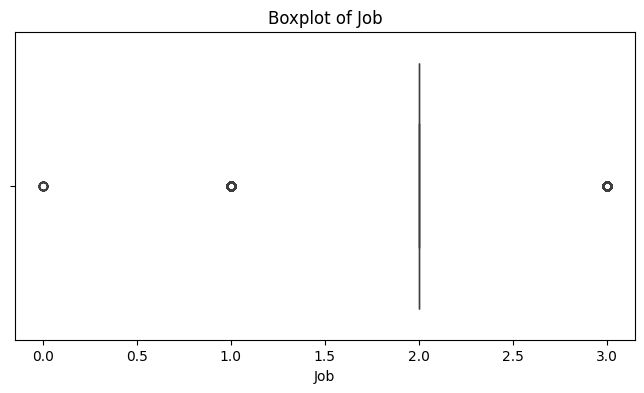

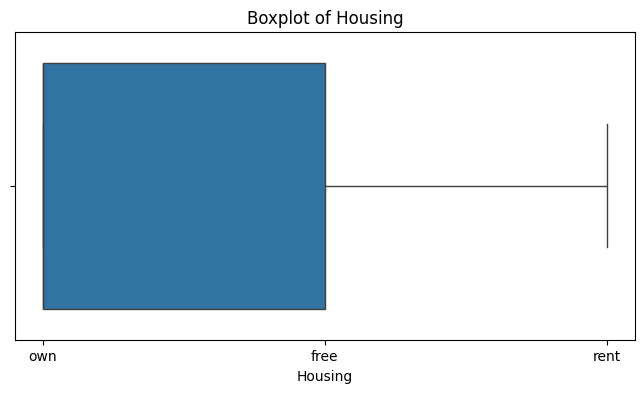

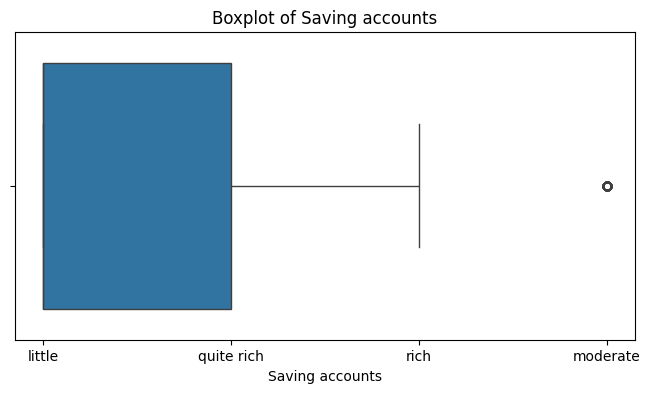

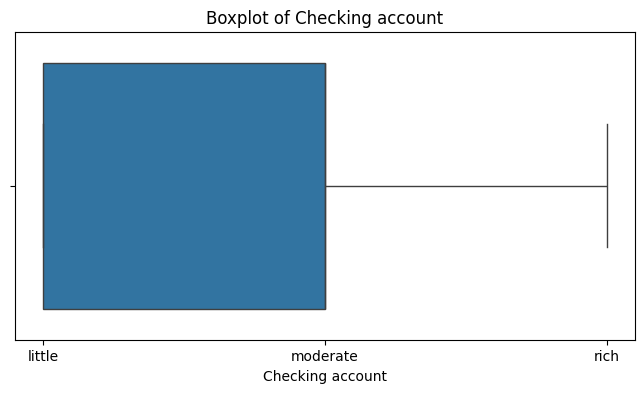

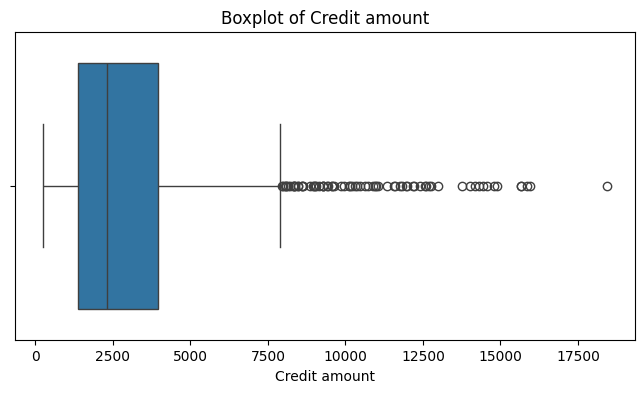

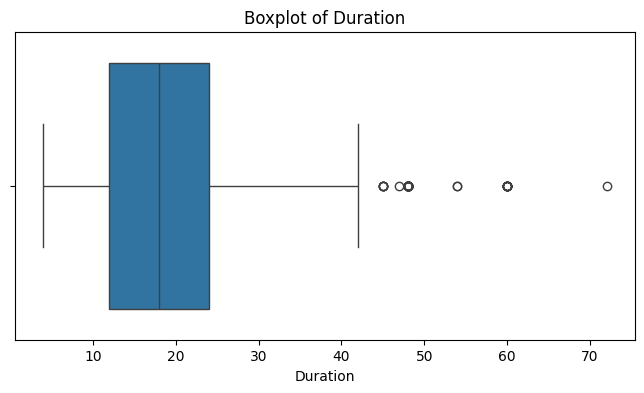

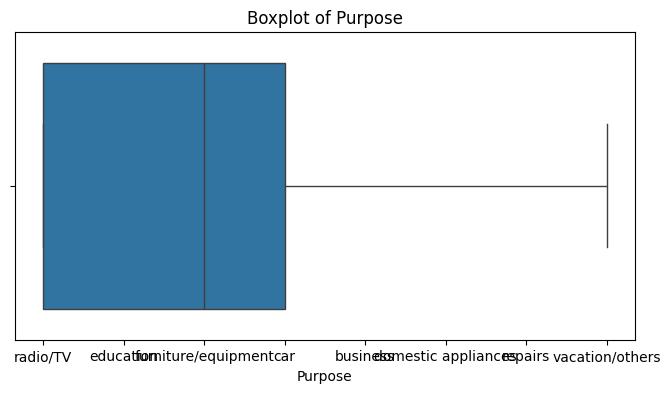

In [250]:
boxplot_cols = z_score_outlier_detect(df, 'Age').columns
for col in boxplot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

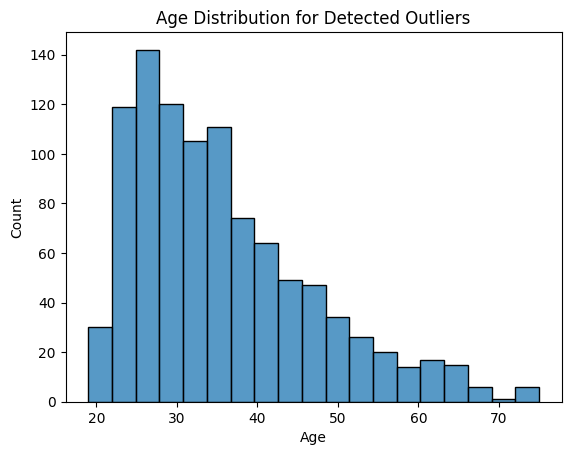

In [251]:
sns.histplot(x=df['Age'])
plt.title("Age Distribution for Detected Outliers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [252]:
df["Age_log"] = np.log1p(df["Age"])

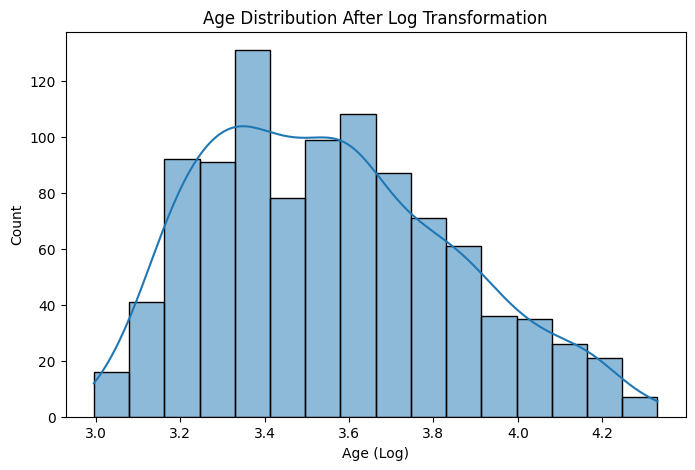

In [253]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["Age_log"], kde=True)

plt.title("Age Distribution After Log Transformation")
plt.xlabel("Age (Log)")
plt.ylabel("Count")

plt.show()

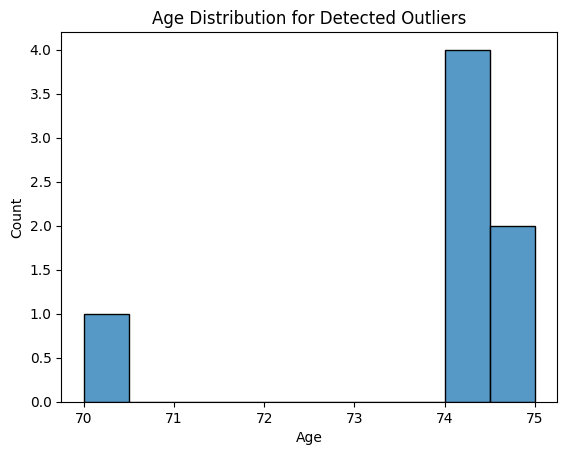

In [254]:
sns.histplot(x=z_score_outlier_detect(df, 'Age')['Age'])
plt.title("Age Distribution for Detected Outliers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [255]:
df = pd.get_dummies(df, drop_first=True)

In [256]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

In [257]:
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 3

for k in range(2,21):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"K = {k} --> Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest K =", best_k)
print("Best Score =", best_score)

K = 2 --> Score = 0.1405
K = 3 --> Score = 0.1098
K = 4 --> Score = 0.1163
K = 5 --> Score = 0.1237
K = 6 --> Score = 0.1558
K = 7 --> Score = 0.1445
K = 8 --> Score = 0.1579
K = 9 --> Score = 0.1747
K = 10 --> Score = 0.1851
K = 11 --> Score = 0.1898
K = 12 --> Score = 0.1969
K = 13 --> Score = 0.1842
K = 14 --> Score = 0.1864
K = 15 --> Score = 0.1769
K = 16 --> Score = 0.1822
K = 17 --> Score = 0.1858
K = 18 --> Score = 0.2069
K = 19 --> Score = 0.1902
K = 20 --> Score = 0.1846

Best K = 18
Best Score = 0.20690045668121515


In [258]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

In [259]:
df.head()

,Age,Job,Credit amount,Duration,Age_log,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,...,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Cluster
0,67,2,1169,6,4.219508,True,True,False,False,False,...,False,False,False,False,False,False,True,False,False,2
1,22,2,5951,48,3.135494,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,0
2,49,1,2096,12,3.912023,True,True,False,False,False,...,False,False,False,False,True,False,False,False,False,2
3,45,2,7882,42,3.828641,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,2
4,53,2,4870,24,3.988984,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,2


In [260]:
df["Cluster"].value_counts()

Cluster
0    515
2    312
1    173
Name: count, dtype: int64

In [261]:
score = silhouette_score(X, clusters)

print("Silhouette Score =", score)

Silhouette Score = 0.10982842977647497


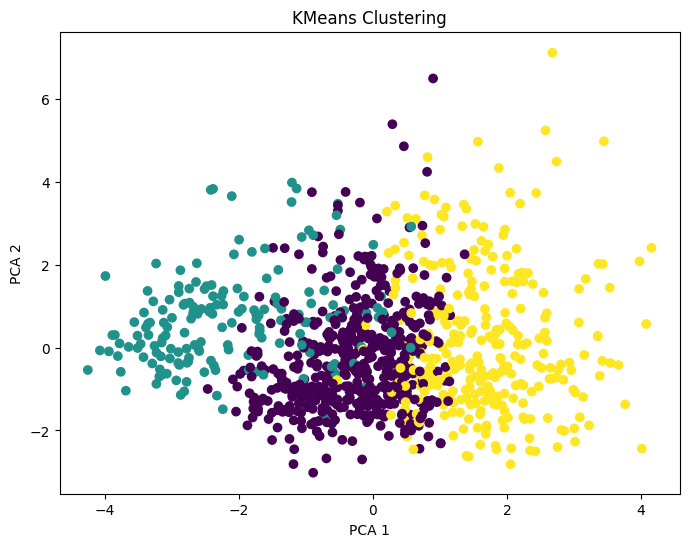

In [262]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("KMeans Clustering")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()